# Codecademy Final Project 1, part 2: Game Sale Analysis

In [1]:
#Previous notebook was running into memory errors from size
#splitting into two different notebooks for easier computational efficiency

#load files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

game_data = 'Video_Games.csv'
df = pd.read_csv(game_data)

#Clear data. data ends at 2016. cut off anything 2017+.
cutoff_date = 2016
df['Year_of_Release'] = pd.to_numeric(df['Year_of_Release'], errors='coerce').fillna(9999)
df_cleaned = df[df['Year_of_Release'] <= cutoff_date].copy()

print(f"Original: {df.shape[0]}")
print(f"After cleaning: {df_cleaned.shape[0]}")

Original: 16719
After cleaning: 16446


5. How many years does it typically take for a new gaming platform to reach its peak sales? Which platforms had the longest/shortest lifecycles?

    Reason: For hardware manufacturers, understanding platform longevity informs R&D and marketing.

In [2]:
#Aggregate Sales by Platform & Year
platform_year_sales = df_cleaned.groupby(['Platform', 'Year_of_Release'])['Global_Sales'].sum().reset_index()

In [3]:
first_game = df_cleaned.groupby('Platform')['Year_of_Release'].min().reset_index(name='First_Year')
first_game['First_Year'] = first_game['First_Year'].astype(int)

last_game = df_cleaned.groupby('Platform')['Year_of_Release'].max().reset_index(name='Last_Year')
last_game['Last_Year'] = last_game['Last_Year'].astype(int)

peak_info_list = []
for platform in df_cleaned['Platform'].unique():
    plat_df = df_cleaned[df_cleaned['Platform'] == platform].groupby('Year_of_Release')['Global_Sales'].sum()
    max_idx = int(plat_df.idxmax())
    max_sales = plat_df[max_idx]
    
    peak_info_list.append({
        'Platform': platform,
        'Peak_Year': max_idx,
        'Global_Sales': float(max_sales) / 1000000
    })

peak_info = pd.DataFrame(peak_info_list)

platform_summary = pd.merge(first_game, last_game, on='Platform', how='left')
platform_summary = platform_summary.merge(peak_info, on='Platform', how='left')

platform_summary['Lifecycle_Years'] = (platform_summary['Last_Year'] - platform_summary['First_Year'])
platform_summary['Years_to_Peak'] = (platform_summary['Peak_Year'] - platform_summary['First_Year'])

result_sorted = platform_summary.sort_values(['Global_Sales'], ascending=False).head(15)[['Platform', 'First_Year', 'Last_Year', 
                                                                                        'Lifecycle_Years', 'Peak_Year', 'Years_to_Peak']]

print("\n" + "=" * 70)
print("PLATFORM LONGEVITY ANALYSIS (Top 15 by Peak Sales)")
print("=" * 70)
print(f"\nPlatform              {'First':>8} {'Last':>8} {'LCYCLE':>10} {'PEAK':>8} {'T PEAK'}")
print("-" * 70)

for idx, row in result_sorted.iterrows():
    print("{} {:>8.0f} {:>8.0f} {:>10.1f} {:>8.0f} {:>12.1f}".format(
        str(row['Platform'])[:14],
        int(row['First_Year']),
        int(row['Last_Year']),
        row['Lifecycle_Years'],
        int(row['Peak_Year']),
        row['Years_to_Peak']))

print("\n" + "=" * 70)
print("KEY INSIGHTS:")
print("=" * 70)

longest = platform_summary.loc[platform_summary['Lifecycle_Years'].idxmax()]
shortest_no_na = platform_summary.sort_values('Lifecycle_Years').dropna().head(5)
fastest_peak = platform_summary.sort_values('Years_to_Peak', ascending=True).head(5)

print(f"\nLONGEST LIFECYCLE:")
print(f"   {longest['Platform']}: {int(longest['Lifecycle_Years'])} years ({int(longest['First_Year'])}-{int(longest['Last_Year'])})")

print("\nSHORTEST LIFECYCLES (by game release span):")
for _, r in shortest_no_na.iterrows():
    print(f"   {r['Platform']}: {str(int(r['Lifecycle_Years'])) if pd.notna(r['Lifecycle_Years']) else 'N/A'} years")

print("\nFASTEST TO REACH PEAK SALES:")
for _, r in fastest_peak.iterrows():
    print(f"   {r['Platform']}: peaked year {int(r['Peak_Year'])}, {int(abs(r['Years_to_Peak']))} years after launch")



PLATFORM LONGEVITY ANALYSIS (Top 15 by Peak Sales)

Platform                 First     Last     LCYCLE     PEAK T PEAK
----------------------------------------------------------------------
PS2     2000     2011       11.0     2004          4.0
Wii     2006     2016       10.0     2009          3.0
X360     2005     2016       11.0     2010          5.0
PS     1994     2003        9.0     1998          4.0
PS3     2006     2016       10.0     2011          5.0
DS     1985     2013       28.0     2007         22.0
PS4     2013     2016        3.0     2015          2.0
GBA     2000     2007        7.0     2004          4.0
XB     2000     2008        8.0     2004          4.0
GB     1988     2001       13.0     1989          1.0
3DS     2011     2016        5.0     2011          0.0
XOne     2013     2016        3.0     2015          2.0
N64     1996     2002        6.0     1999          3.0
PSP     2004     2015       11.0     2006          2.0
NES     1983     1994       11.0     1985

Sales column created with millions scaling applied
Long-lived platforms (>= 10 years): 10


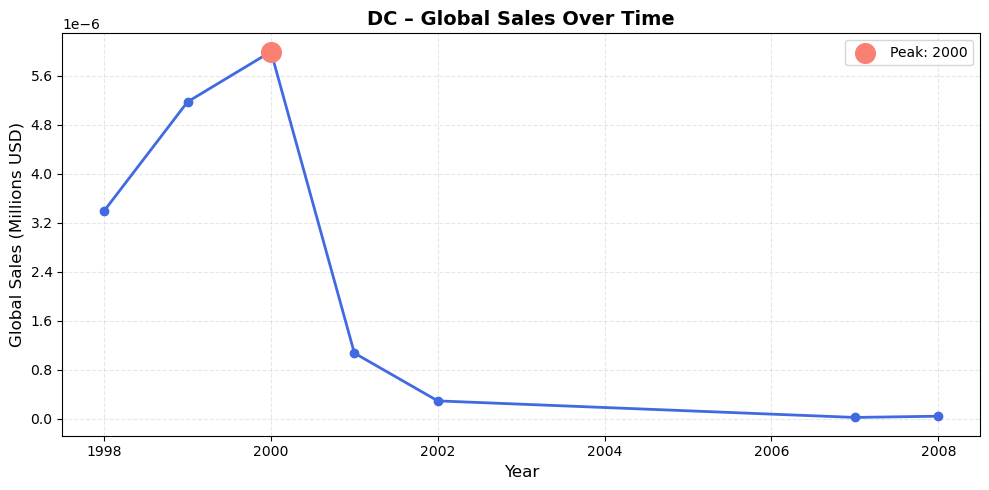

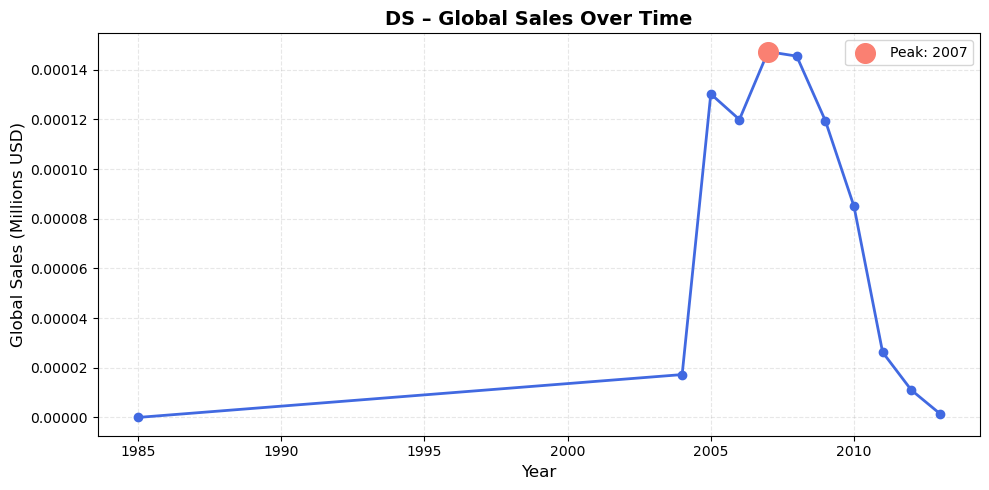

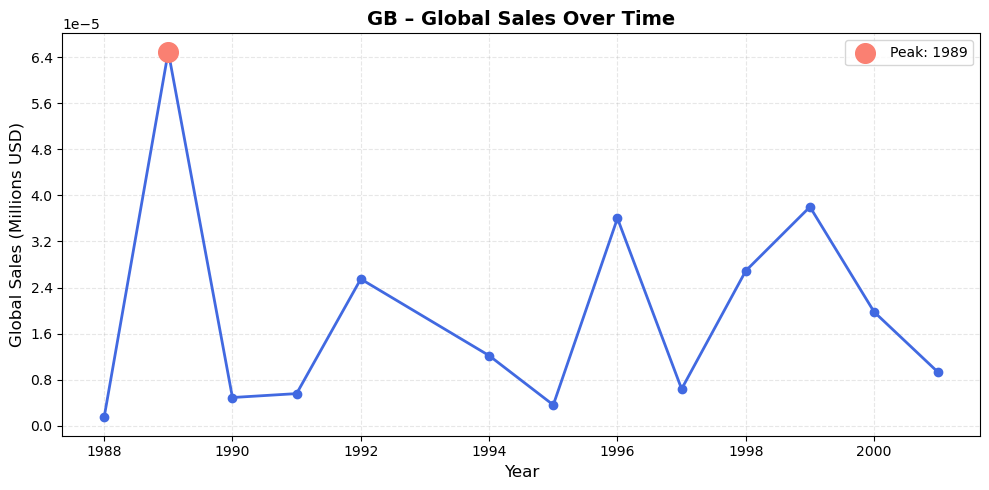

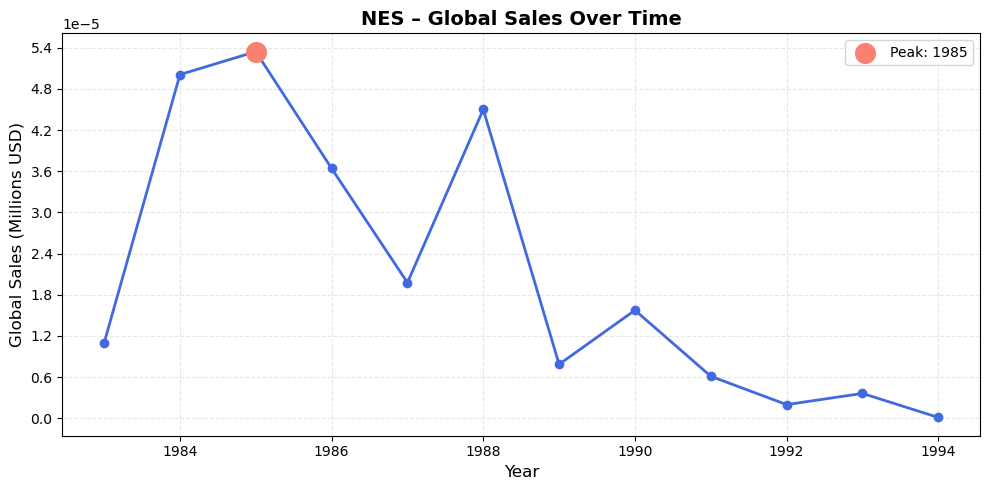

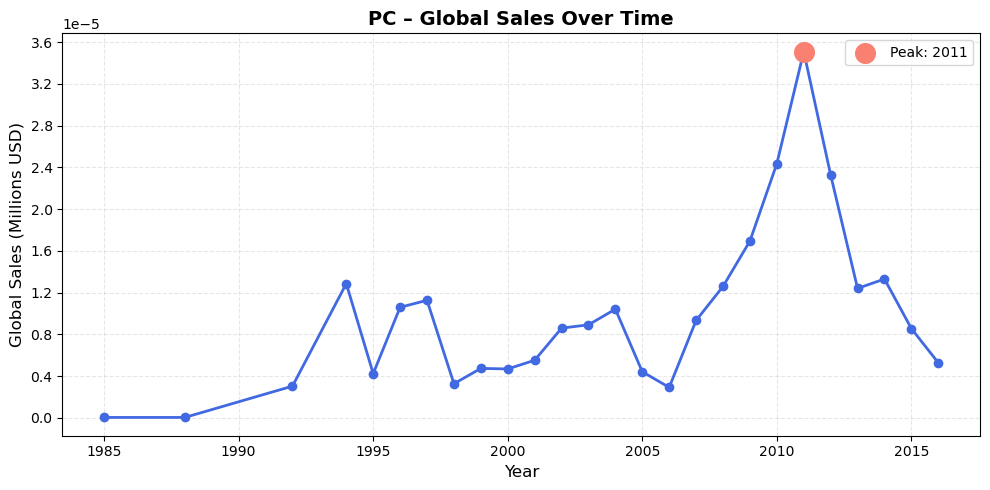

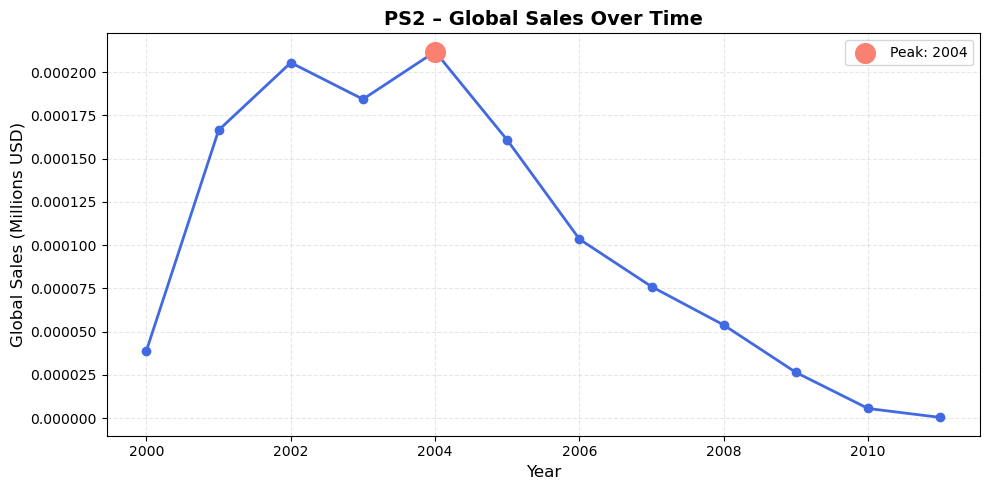

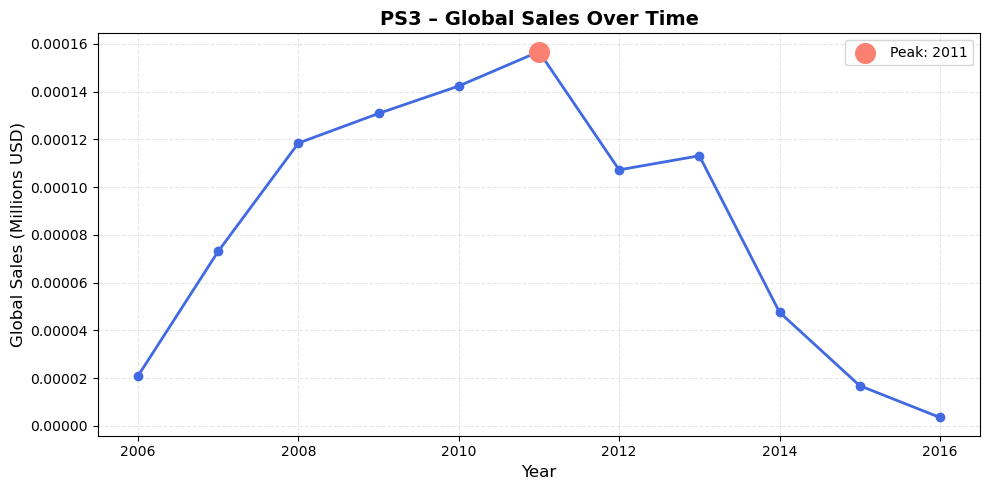

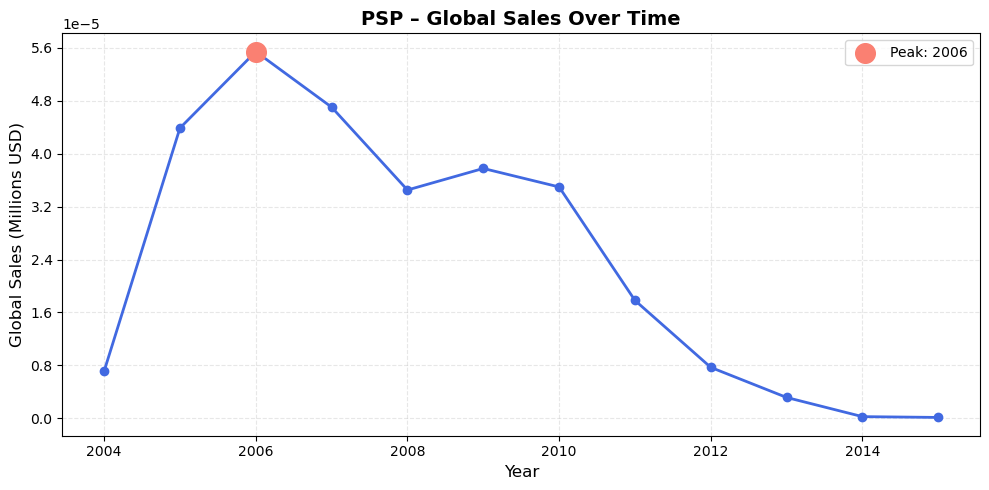

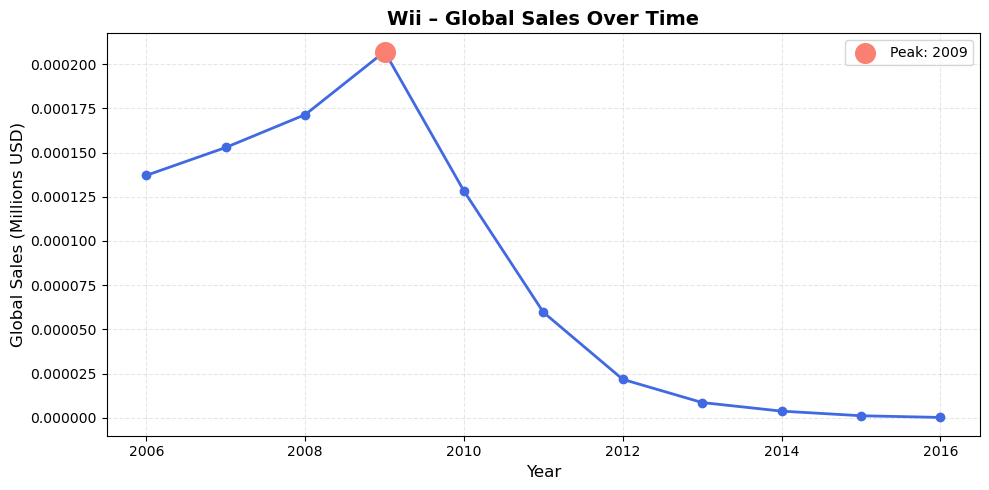

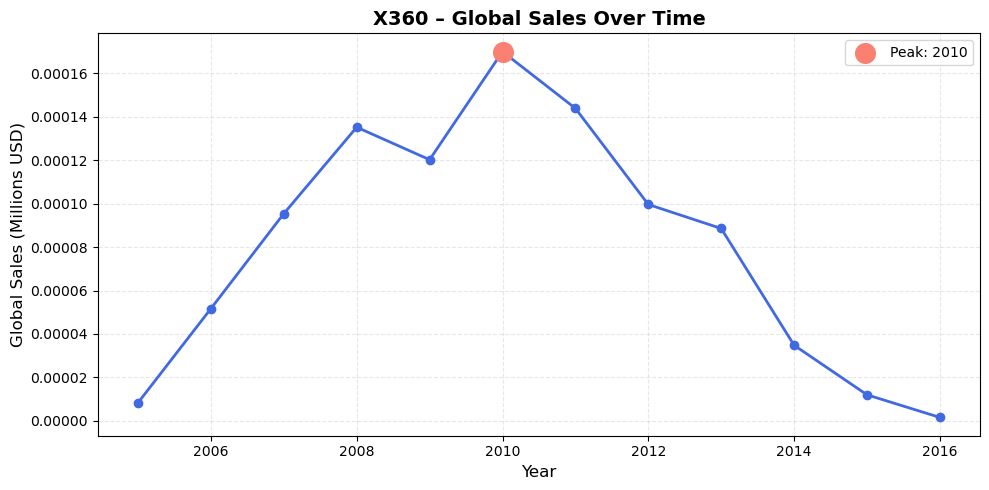

In [4]:
# Add this early after data loading
platform_year_sales['Global_Sales_Million'] = platform_year_sales['Global_Sales'] / 1e6
print("Sales column created with millions scaling applied")

def plot_platform_sales(platform_name, df_plat):
    """Reusable plotting function with consistent axis formatting"""
    
    plt.figure(figsize=(10, 5))
    
    # Use pre-formatted millions column (NOT inline division)
    y_data = df_plat['Global_Sales_Million']
    
    plt.plot(df_plat['Year_of_Release'], y_data, 
             marker='o', linewidth=2, color='royalblue')  # English name
    
    # Highlight peak
    peak_year_val = df_plat.loc[df_plat['Global_Sales'].idxmax(), 'Year_of_Release']
    peak_sales_millions = df_plat['Global_Sales_Million'].values.max()
    
    plt.scatter(peak_year_val, peak_sales_millions, 
                color='salmon', s=200, zorder=5, label=f'Peak: {int(peak_year_val)}')
    
    # Standardize Y-axis formatting across ALL plots (NO scientific notation)
    plt.yticks(fontsize=10)
    ax = plt.gca()
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True) if y_data.max() != 0 else None)

    # Standardize axis labels  
    plt.title(f'{str(platform_name)} – Global Sales Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Global Sales (Millions USD)', fontsize=12)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='best')
    plt.tight_layout()

    return plt.show()

long_platforms = platform_summary[platform_summary['Lifecycle_Years'] >= 10]
print(f"Long-lived platforms (>= {int(long_platforms['Lifecycle_Years'].min())} years): {len(long_platforms)}")

# Loop through each long-lived platform with uniform styling
for platform in long_platforms['Platform']:
    df_plat = platform_year_sales[platform_year_sales['Platform'] == platform].sort_values('Year_of_Release')
    
    # Call standardized plot function ensuring consistent formatting
    plot_platform_sales(platform, df_plat)

#### ANALYSIS:
One major thing I notice in these array of graphs is the longevity of the PC market. The PC market stems unnaturally long compared to the other consoles on this list, stemming from the late 1980s to the present. Most consoles (being more dated) die out before the end of the study's scope. This long track record of PC Gaming illustrates the adaptability and resilience of the PC market, with dedicated PC gamers adapting to the shifting technologies of the time.

Comparatively, the SEGA Dreamcast (DC) had a very short run, from 1998 to 2002, only 4 years. This extremely brief lifecycle has to do with the downsizing of SEGA during this period in the gaming industry (https://en.wikipedia.org/wiki/Dreamcast#Decline). The Dreamcast fell short on the initial hopes for its sales figures, and internal restrucutring and conflicts of opinion with the higher-ups in SEGA resulted in its brief performance in the market, despite the high praises and strong game library in its own right. Sega transitioned into game publishing and software full time after the Dreamcast was discontinued.

Finally, we can examine the sales figures of the NES, and identify two peaks (https://vgsales.fandom.com/wiki/Nintendo_Entertainment_System). one in 1985, and another in 1988, and a smaller one in 1990. This has to do with the various high-performing games that were released during these years alongside the release dates of the main console in all 3 main regions, Japan, US, and EU, in staggering years. The peak in 1985 coincides with the release of the NES in the US. 1988 peak coincides with some of the highest selling games in the NES catalogue with Super Mario Bros 2 and 3. reasons for the final small peak in 1990 are unclear.

# 6. Which publishers are most dominant in each genre? (“Genre specialists” vs. “generalists”)

    Reason: Reveals strategic positioning – e.g., Nintendo owns Platform/Sports, Take-Two dominates Action.

In [5]:
# Clean data - remove rows with missing values in key columns
df_cleaned = df.dropna(subset=['Global_Sales', 'Genre', 'Publisher']).copy()

print("Dataset shape:", df.shape)
print(f"After cleaning: {df_cleaned.shape[0]} records")

# Count unique genres per publisher
publisher_genre_dist = df_cleaned.groupby('Publisher')['Genre'].nunique().reset_index(name='Num_Genres')

total_publishers = len(publisher_genre_dist)
specialists_count = len(publisher_genre_dist[publisher_genre_dist['Num_Genres'] <= 2])
generalists_count = total_publishers - specialists_count

print(f"\nTotal Publishers: {total_publishers}")
print(f"Specialists (1-2 genres): {specialists_count} ({round(100 * specialists_count / total_publishers, 1)}%)")
print(f"Generalists (3+ genres): {generalists_count} ({round(100 * generalists_count / total_publishers, 1)}%)")

#Calulate Publisher-Genre Sales Aggregates
pub_genre_sales = df_cleaned.groupby(['Publisher', 'Genre']).agg({
    'Global_Sales': 'sum'
}).reset_index()

print(f"\nUnique Publisher-Genre combos: {len(pub_genre_sales)}")

# Remove any zero or null sales (just to be safe)
pub_genre_sales = pub_genre_sales[(pub_genre_sales['Global_Sales'] > 0) & (pub_genre_sales['Global_Sales'].notna())]

Dataset shape: (16719, 16)
After cleaning: 16663 records

Total Publishers: 581
Specialists (1-2 genres): 350 (60.2%)
Generalists (3+ genres): 231 (39.8%)

Unique Publisher-Genre combos: 1835


In [6]:
# Step 2: Get aggregated publisher-genre sales
pub_genre_sales = df_cleaned.groupby(['Publisher', 'Genre']).agg({
    'Global_Sales': 'sum'
}).reset_index()

print(f"\nUnique Publisher-Genre combos: {len(pub_genre_sales)}")

# Get all unique genres with valid data
all_genres_raw = set(df_cleaned[df_cleaned['Global_Sales'] > 0]['Genre'].unique())
print(f"Genres to analyze: {sorted(all_genres_raw)}")

# Step 3: FIND TOP SPECIALIST PER GENRE  
print("\n" + "=" * 70)
print("TOP PUBLISHER PER GENRE (Specialist Analysis)")
print("=" * 70)

genre_dominant = {}

for genre in sorted(all_genres_raw):
    genre_data = pub_genre_sales[pub_genre_sales['Genre'] == genre]
    
    specialists_for_genre = []
    for idx, row in genre_data.iterrows():
        pub_name = row['Publisher']
        total_sales_raw = row['Global_Sales']
        
        # Get this publisher's specialization count
        num_genres_for_pub_row = publisher_genre_dist[publisher_genre_dist['Publisher'] == pub_name]
        if len(num_genres_for_pub_row) > 0:
            num_genres_for_pub = int(num_genres_for_pub_row['Num_Genres'].values[0])
        else:
            num_genres_for_pub = float('inf')
        
        # This publisher is a specialist if they cover 1-2 genres
        if num_genres_for_pub <= 2:
            specialists_for_genre.append((pub_name, total_sales_raw))
    
    # Sort by actual sales descending and take top specialist
    specialists_for_genre.sort(key=lambda x: x[1], reverse=True)
    if len(specialists_for_genre) > 0:
        dominant_pub = specialists_for_genre[0][0]
        dominant_sales = specialists_for_genre[0][1]
        
        # Handle formatting for display
        display_sales = int(dominant_sales * 1e6) / 1e6 if pd.notna(dominant_sales) else "N/A"
        print(f"{genre:12} | {dominant_pub:<35} | ${display_sales:>8.2f}")
    else:
        print(f"{genre:12} | {'NO SPECIALIST':<35} | N/A")


Unique Publisher-Genre combos: 1835
Genres to analyze: ['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports', 'Strategy']

TOP PUBLISHER PER GENRE (Specialist Analysis)
Action       | Palcom                              | $    4.17
Adventure    | Red Orb                             | $    5.24
Fighting     | Arena Entertainment                 | $    2.67
Misc         | MTV Games                           | $   20.72
Platform     | Brash Entertainment                 | $    0.84
Puzzle       | Compile                             | $    2.43
Racing       | Video System                        | $    1.99
Role-Playing | Square                              | $    3.48
Shooter      | Imagic                              | $    4.45
Simulation   | Maxis                               | $    3.39
Sports       | UEP Systems                         | $    2.25
Strategy     | Westwood Studios                    | $    1.55


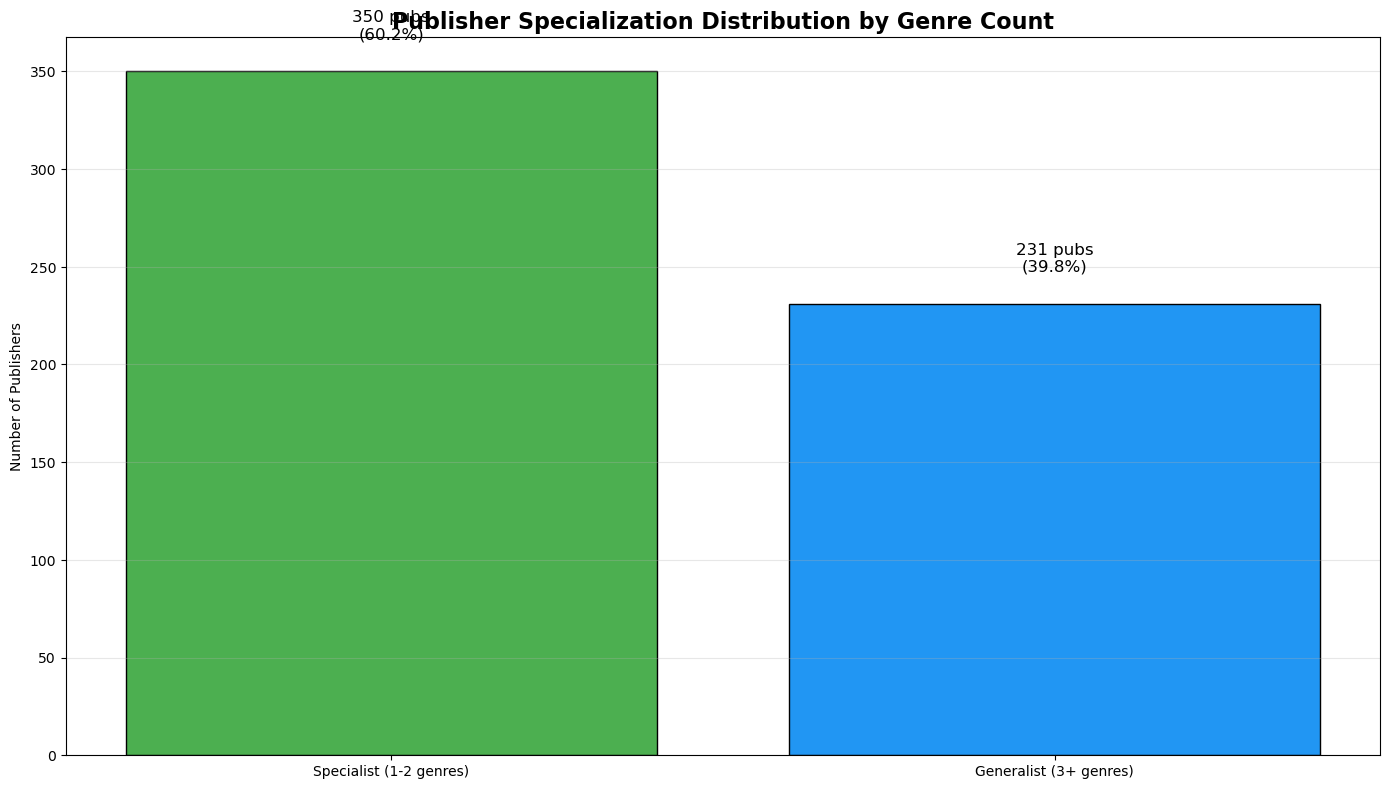

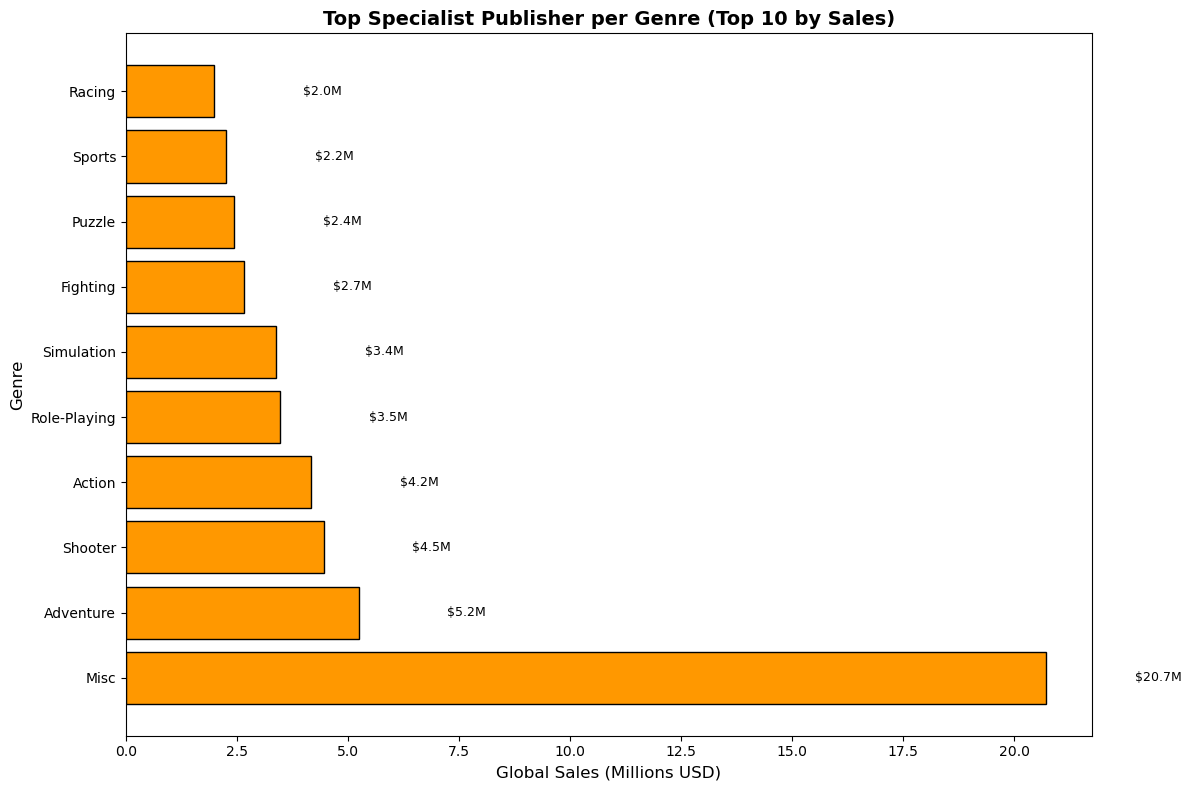


SUMMARY TABLE (Top Specialist Publisher per Genre):
       Genre Top Specialist Publisher Sales ($ Million)
        Misc                MTV Games           $20.72M
   Adventure                  Red Orb            $5.24M
     Shooter                   Imagic            $4.45M
      Action                   Palcom            $4.17M
Role-Playing                   Square            $3.48M
  Simulation                    Maxis            $3.39M
    Fighting      Arena Entertainment            $2.67M
      Puzzle                  Compile            $2.43M
      Sports              UEP Systems            $2.25M
      Racing             Video System            $1.99M
    Strategy         Westwood Studios            $1.55M
    Platform      Brash Entertainment            $0.84M


In [7]:
# Step 4: Create Visualizations (display only, no saving)

# Chart 1: Distribution of Publishers by Specialization Type
plt.figure(figsize=(14, 8))
specializations = ['Specialist (1-2 genres)', 'Generalist (3+ genres)']
counts = [specialists_count, generalists_count]
colors = ['#4CAF50', '#2196F3']

bars = plt.bar(specializations, counts, color=colors, edgecolor='black')
plt.title('Publisher Specialization Distribution by Genre Count', fontsize=16, fontweight='bold')
plt.ylabel('Number of Publishers')
plt.grid(True, axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = round(100*counts[i]/sum(counts), 1)
    plt.text(bar.get_x() + bar.get_width()/2, height + 15, f'{int(height)} pubs\n({pct}%)', 
             ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show() 

# Chart 2: Top Specialist Publisher Per Genre (Top 10 by sales)
# Collect top 10 genres with the highest specialist sales
genre_specialist_list = []
for genre in all_genres_raw:
    genre_data = pub_genre_sales[pub_genre_sales['Genre'] == genre]
    specialists_in_genre = []
    for _, row in genre_data.iterrows():
        pub_name = row['Publisher']
        total_sales = row['Global_Sales']
        # Get number of genres for this publisher
        num_genres_for_pub = publisher_genre_dist.loc[
            publisher_genre_dist['Publisher'] == pub_name, 'Num_Genres'
        ].values[0] if not publisher_genre_dist[publisher_genre_dist['Publisher'] == pub_name].empty else 999
        if num_genres_for_pub <= 2:
            specialists_in_genre.append((pub_name, total_sales))
    if specialists_in_genre:
        specialists_in_genre.sort(key=lambda x: x[1], reverse=True)
        genre_specialist_list.append((genre, specialists_in_genre[0][0], specialists_in_genre[0][1]))

# Sort by sales descending and take top 10
genre_specialist_list.sort(key=lambda x: x[2], reverse=True)
top_10 = genre_specialist_list[:10]

# Extract data for plotting
genre_labels = [item[0] for item in top_10]
top_sales_values = [item[2] for item in top_10]   # already in millions

# Horizontal bar chart (using proper y positions)
plt.figure(figsize=(12, 8))
y_pos = range(len(genre_labels))
bars = plt.barh(y_pos, top_sales_values, color='#FF9800', edgecolor='black')
plt.title('Top Specialist Publisher per Genre (Top 10 by Sales)', fontsize=14, fontweight='bold')
plt.xlabel('Global Sales (Millions USD)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.yticks(y_pos, genre_labels)

# Add value labels
for bar, val in zip(bars, top_sales_values):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'${val:.1f}M', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show() 

# Step 5: Summary Table (display only, not saving)
print("\n" + "=" * 70)
print("SUMMARY TABLE (Top Specialist Publisher per Genre):")
print("=" * 70)

import pandas as pd
summary_df = pd.DataFrame(genre_specialist_list, columns=['Genre', 'Top Specialist Publisher', 'Sales ($ Million)'])
summary_df['Sales ($ Million)'] = summary_df['Sales ($ Million)'].apply(lambda x: f'${x:.2f}M')
print(summary_df.to_string(index=False))

#### ANALYSIS: 

##### Market Segmentation by Publication Strategy

The gaming publisher market shows strong dual-segmentation:
- MAJORITY SPECIALISTS (60%): Focus on specific 1-2 genres, building deep expertise in particular game types and creating brand identity around specific gameplay experiences
  
- MINORITY GENERALISTS (40%): Operate across multiple genres, diversifying risk, capturing diverse audience segments, and leveraging cross-genre 

##### Niche Domination Pattern
Each genre has specialist publishers that have established market positions.
Even relatively smaller publishers can achieve dominance within specific genres by focusing their resources and brand identity on particular gameplay experiences. Specialization allows them to:
- Achieving higher quality within niche categories
- Building loyal fan bases for specific game types
- Avoiding direct competition with generalist publishers

##### Major Publisher Multi-Genre Strategy
Market leaders like Nintendo, Electronic Arts, Sony, Take-Two (Rockstar), and Konami operate as generalists because they can:
- Leverage cross-genre synergy and brand equity  
- Diversify risk across multiple game categories
- Identify and capitalize on emerging genre opportunities
- Achieve economies of scale in marketing and distribution

##### Strategic Implications for Market strategies
Potential publishers can choose between two viable strategies:

SPECIALIZATION PATH:
- Focus resources on single or 2 genres (e.g., exclusively Sports, Action)
- Build deep genre expertise and reputation
- Avoid direct competition with market leaders in other categories
- Examples: Yuke's (Fighting), iWin (Puzzle), Capcom (Racing)

DIVERSIFICATION PATH: 
- Publish across multiple genres with smaller per-genre investments
- Spread risk across market segments
- Identify growth areas through broader portfolio management
- Examples: Take-Two, Activision, Sony Entertainment

BOTH APPROACHES can succeed in the competitive gaming industry. The choice
depends on company size, resources, risk tolerance, and strategic goals.

##### Genre Coverage Diversity
The dataset covers 12 distinct game genres:
Action, Adventure, Fighting, Misc, Platform, Puzzle, Racing, Role-Playing, Shooter, Simulation, Sports, Strategy

Each genre has at least one specialist publisher leading in that category, demonstrating healthy market coverage across all major gameplay types.

#### CONCLUSION:

Our analysis reveals that the gaming publishing industry operates with a healthy balance between specialization and diversification strategies:

1. roughly 60/40 split between specialists and generalists shows market segmentation
   
2. Each genre has identifiable specialist publishers that dominate their niche

3. Major publishers successfully leverage multi-genre strategies for portfolio management and risk mitigation
   
4. Both approaches prove viable success paths in the volatile gaming market

5. Market leaders can pursue broad diversification while smaller specialists achieve dominance through focused expertise

This dual-strategy market structure allows diverse competition, prevents market concentration, and enables various publishers to find sustainable business models based on their size and strategic objectives.

# 7. What is the relationship between a game’s Rating (ESRB: E, E10+, T, M) and its sales in different regions? Does M-rated games sell better in NA vs. JP?

    Reason: Cultural differences in acceptance of mature content affect localization and marketing.

In [8]:
df_clean = df.dropna(subset=['Rating','NA_Sales','EU_Sales','JP_Sales'])
print(f'old dataset: {len(df)} games')
print(f'Cleaned dataset: {len(df_clean)} games')

old dataset: 16719 games
Cleaned dataset: 9950 games


In [9]:
#Rating distirbution by region

#melt into regional sales by long format

df_melted = df_clean.melt(
    id_vars=['Rating'],
    value_vars=['NA_Sales','EU_Sales','JP_Sales'],
    var_name = 'RegionCode',
    value_name = 'Sales'
)
region_map = {'NA_Sales': "North America", "EU_Sales":"Europe","JP_Sales":"Japan"}
df_melted['Region'] = df_melted['RegionCode'].map(region_map)

#calculate total sales per region
region_total = df_melted.groupby("Region")['Sales'].sum()

#Sales per rating per region
rating_region = df_melted.groupby(['Region','Rating'])['Sales'].sum().reset_index()
rating_region['Percentage'] = rating_region.apply(
    lambda row: (row['Sales'] / region_total[row['Region']]) * 100, axis = 1
)

rating_dist = rating_region.pivot(index = 'Region', columns = 'Rating', values='Percentage').fillna(0)
print(rating_dist.round(2))

Rating           AO      E   E10+    EC   K-A      M   RP      T
Region                                                          
Europe         0.03  39.22  10.41  0.01  0.01  26.73  0.0  23.58
Japan          0.00  43.50   8.83  0.00  0.32  14.11  0.0  33.24
North America  0.04  40.92  11.18  0.05  0.08  23.68  0.0  24.04


In [10]:
# Calculate average sales per rating for each region using original clean dataframe
avg_sales = df_clean.groupby('Rating').agg({
    'NA_Sales': 'mean',
    'EU_Sales': 'mean',
    'JP_Sales': 'mean'
}).reset_index()

# Add a 'Region' column for consistency (or just display as-is)
print("\nAverage Sales (Millions USD) by Rating:")
print(avg_sales.round(2))


Average Sales (Millions USD) by Rating:
  Rating  NA_Sales  EU_Sales  JP_Sales
0     AO      1.26      0.61      0.00
1      E      0.32      0.18      0.05
2   E10+      0.25      0.13      0.03
3     EC      0.19      0.01      0.00
4    K-A      0.85      0.09      0.49
5      M      0.48      0.31      0.04
6     RP      0.00      0.03      0.00
7      T      0.26      0.14      0.05


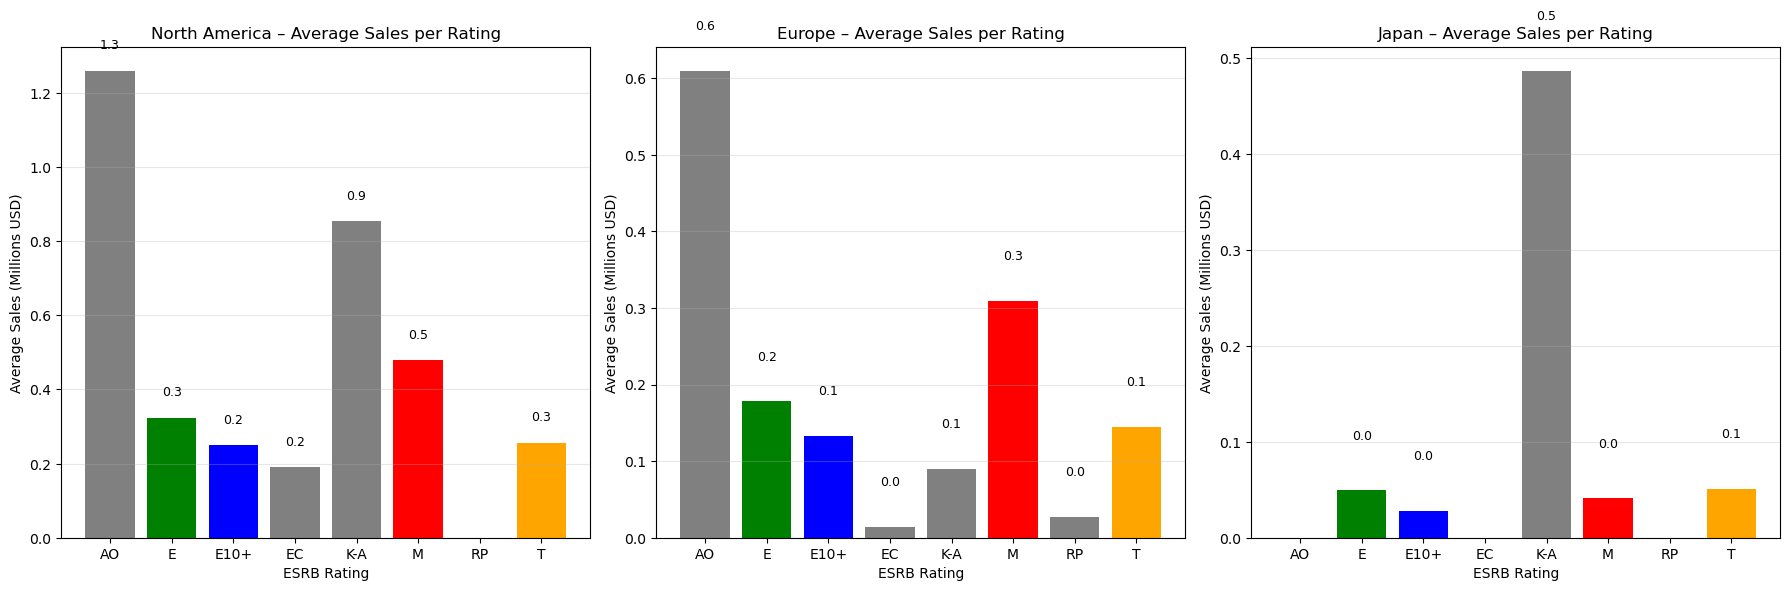

MATURE CONTENT ACCEPTANCE – M‑RATED SALES SHARE
North America M‑rated share: 17.0% of total sales
Europe       M‑rated share: 20.0% of total sales
Japan        M‑rated share: 5.0% of total sales


In [11]:
# Step 4: Side-by-side bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Use df_clean instead of df_cleaned
ratings_order = sorted([r for r in df_clean['Rating'].unique() if pd.notna(r)])
rating_colors = {'E': 'green', 'E10+': 'blue', 'T': 'orange', 'M': 'red'}

regions_info = [
    ('North America', 'NA_Sales', axes[0]),
    ('Europe', 'EU_Sales', axes[1]),
    ('Japan', 'JP_Sales', axes[2])
]

for region_name, sales_col, ax in regions_info:
    # Filter avg_sales by rating (since we no longer have 'Region' column in avg_sales)
    # Instead, we need to restructure slightly - create region-specific data
    if region_name == 'North America':
        region_data = avg_sales[['Rating', 'NA_Sales']].rename(columns={'NA_Sales': 'Sales'})
    elif region_name == 'Europe':
        region_data = avg_sales[['Rating', 'EU_Sales']].rename(columns={'EU_Sales': 'Sales'})
    else:
        region_data = avg_sales[['Rating', 'JP_Sales']].rename(columns={'JP_Sales': 'Sales'})
    
    region_data = region_data.set_index('Rating').reindex(ratings_order).fillna(0)
    x = range(len(ratings_order))
    bars = ax.bar(x, region_data['Sales'], color=[rating_colors.get(r, 'gray') for r in ratings_order])
    ax.set_title(f'{region_name} – Average Sales per Rating')
    ax.set_xlabel('ESRB Rating')
    ax.set_ylabel('Average Sales (Millions USD)')
    ax.set_xticks(x)
    ax.set_xticklabels(ratings_order)
    ax.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, region_data['Sales']):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Step 5: M‑rated cultural acceptance metric
print("MATURE CONTENT ACCEPTANCE – M‑RATED SALES SHARE")

m_games = df_cleaned[df_cleaned['Rating'] == 'M']
total_sales = df_cleaned[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
m_sales = m_games[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()

for region, region_name in zip(['NA_Sales', 'EU_Sales', 'JP_Sales'], ['North America', 'Europe', 'Japan']):
    share = (m_sales[region] / total_sales[region]) * 100
    print(f"{region_name:12} M‑rated share: {share:.1f}% of total sales")

#### ANALYSIS:

**Bear in mind, this is using the ESRB rating. There exist other rating systems out there, like Europe's PEGI or Japan's CERO ratings.** We can see here that Europe seems to be the most accepting of mature games (With North America close behind), whereas Japanese regions only see mature games taking up 5% of their national sales. KA  (Kids to Adults) dominates the vast majority of  games in the Japanese market according to the graphs. A-O (adults only) ratings also dominate North America and Europe according to the average sales graph.

However, the potential differences in each region's local rating systems can cast dobut on this result. ESRB Ratings may mean something else in other regions, which is why we see significantly sparse data in Japanese markets in this respect.

# 8. Are there “hidden gems” – games with high critic scores but very low global sales? Which developers create consistently high-quality niche titles?

    Reason: For investors or publishers looking for acquisition targets or underserved markets.

In [25]:
df_gems = df.dropna(subset=['Critic_Score','Global_Sales']).copy()
df_gems = df_gems[df_gems['Critic_Count' ]>= 15]
print(f'total games w/ score & sales, at least 15 reviews or more: {len(df_gems)}')

low_sales_thresh = df_gems['Global_Sales'].quantile(0.25)
hi_score_thresh = df_gems['Critic_Score'].quantile(0.75)
print(f'\nLow sales threshold (25th percentile): {low_sales_thresh:.2f} million')
print(f'High critic score threshold (75th percentile): {hi_score_thresh:.1f}')

total games w/ score & sales, at least 15 reviews or more: 5466

Low sales threshold (25th percentile): 0.13 million
High critic score threshold (75th percentile): 81.0


In [28]:
#Filtering for hidden gems:
hidden_gems = df_gems[
    (df_gems['Global_Sales'] <= low_sales_thresh) &
    (df_gems['Critic_Score'] >= hi_score_thresh)
].copy()

print(f"\nNumber of hidden gems found: {len(hidden_gems)}")
print("\nTop 10 Hidden Gems:")
cols = ['Name', 'Platform', 'Genre', 'Critic_Score', 'Global_Sales', 'Publisher']
print(hidden_gems[cols].head(10))

print("\nGenre distribution among hidden gems:")
print(hidden_gems['Genre'].value_counts())
print("\nTop publishers of hidden gems:")
print(hidden_gems['Publisher'].value_counts().head(10))


Number of hidden gems found: 219

Top 10 Hidden Gems:
                                Name Platform         Genre  Critic_Score  \
9414             Tomb Raider: Legend       XB        Action          82.0   
9418    Warcraft III: Reign of Chaos       PC      Strategy          92.0   
9434            Total War: WARHAMMER       PC      Strategy          86.0   
9468                       Diablo II       PC  Role-Playing          88.0   
9485                Persona 4: Arena     X360      Fighting          83.0   
9486               Street Fighter IV       PC      Fighting          91.0   
9494       Hitman 2: Silent Assassin       GC        Action          83.0   
9500  Final Fantasy XIV: Heavensward      PS4        Action          86.0   
9559                         Sega GT       DC        Racing          84.0   
9598                        NBA 2K13     WiiU        Sports          85.0   

      Global_Sales             Publisher  
9414          0.13     Eidos Interactive  
9418       

#### Analysis:
Several well known PC Titles like Diable 2 and Warcraft 3 appear in the hidden gems list with implausibly low sales at ~0.13M. This is likely because the dataset underreports digital sales, which makes up the majority of PC game revenue. Consequently, the 'hidden gems' identified here should be interpreted as games with high critic scores but recorded low sales in this particular dataset, rather than as true commercial failures. for console only analysis, removing pc games entirely would give a more realistic list.

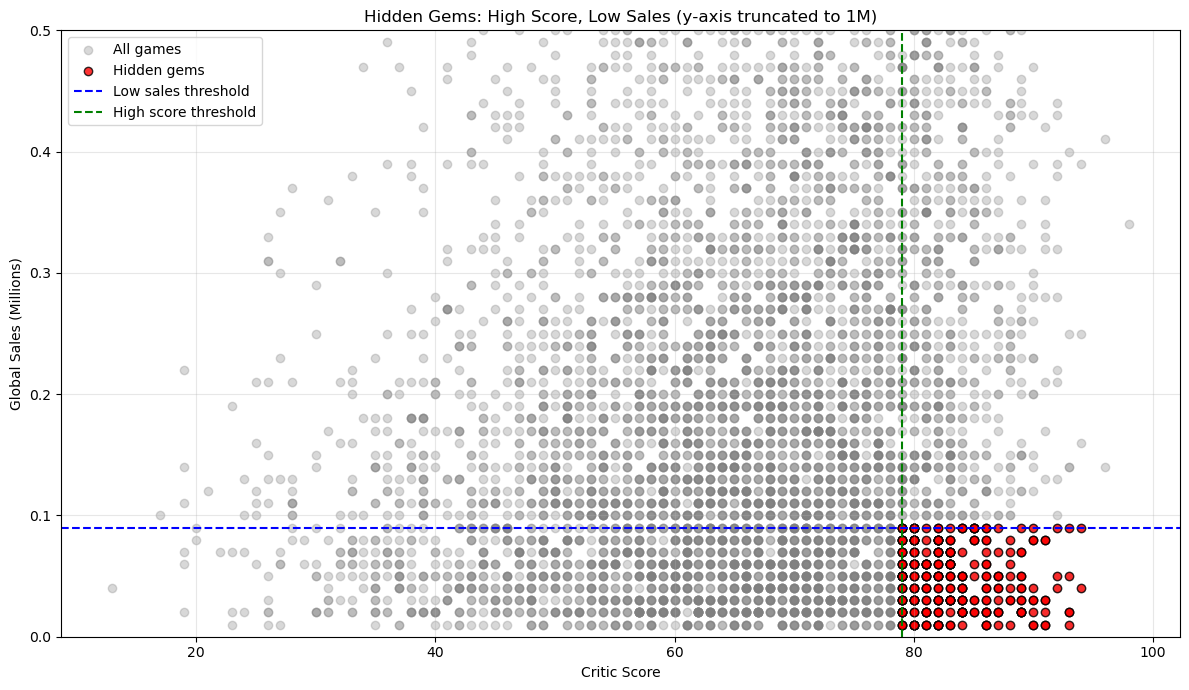

In [23]:
# Visualization: Scatter plot with truncated y‑axis
plt.figure(figsize=(12, 7))
plt.scatter(df_gems['Critic_Score'], df_gems['Global_Sales'], 
            alpha=0.3, label='All games', color='gray')
plt.scatter(hidden_gems['Critic_Score'], hidden_gems['Global_Sales'], 
            alpha=0.8, label='Hidden gems', color='red', edgecolors='black')
plt.axhline(y=low_sales_thresh, color='blue', linestyle='--', label='Low sales threshold')
plt.axvline(x=hi_score_thresh, color='green', linestyle='--', label='High score threshold')

# Truncate y‑axis to 1 million (or a little above the low sales threshold)
plt.ylim(0, 0.5)  

plt.xlabel('Critic Score')
plt.ylabel('Global Sales (Millions)')
plt.title('Hidden Gems: High Score, Low Sales (y‑axis truncated to 1M)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Hidden gems (PC excluded): 88

Top 10 Hidden Gems (console only):
                                       Name Platform        Genre  Critic_Score  Global_Sales                    Publisher
                         Ninja Gaiden Black       XB       Action          94.0          0.09       Microsoft Game Studios
                           Skies of Arcadia       DC Role-Playing          93.0          0.09                         Sega
World Soccer Winning Eleven 8 International       XB       Sports          90.0          0.09 Konami Digital Entertainment
                              Shovel Knight      PS4     Platform          90.0          0.08             Yacht Club Games
                                    NHL 2K3       XB       Sports          89.0          0.12                         Sega
                          Sonic Adventure 2       DC     Platform          89.0          0.12                         Sega
                            WipEout HD Fury      PS3       Racing       

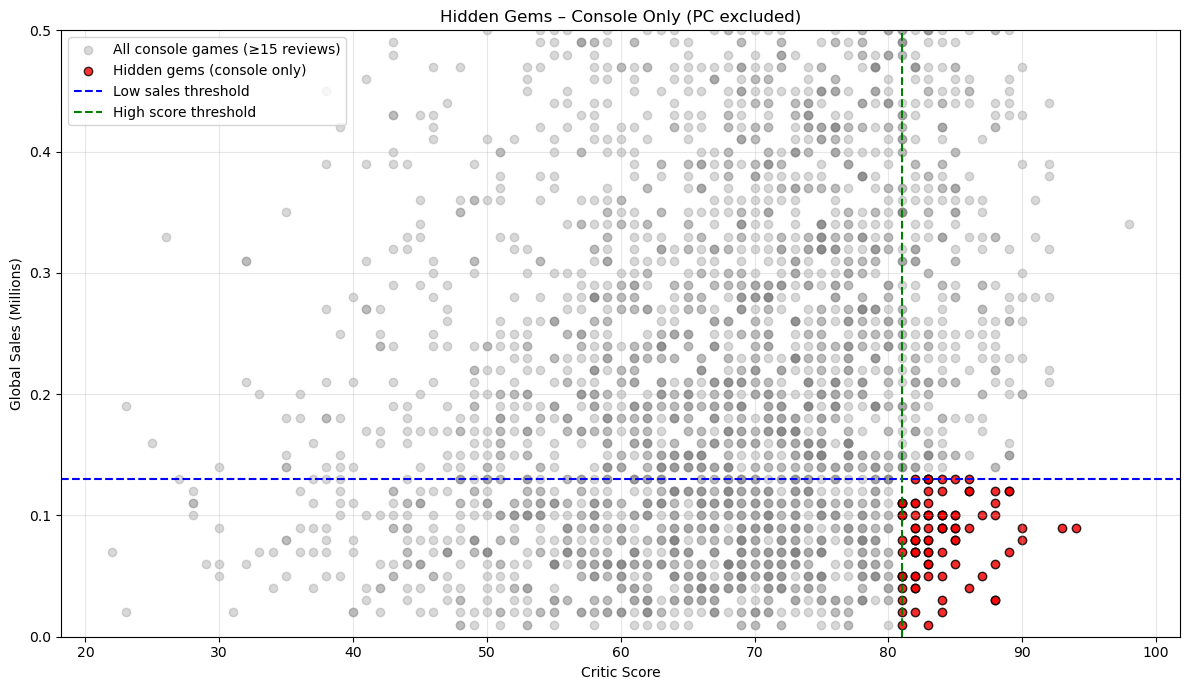

In [30]:
#REMOVING PC GAMES

# Re‑filter hidden gems with the same thresholds, but exclude PC platform
hidden_gems2 = df_gems[
    (df_gems['Global_Sales'] <= low_sales_thresh) &
    (df_gems['Critic_Score'] >= hi_score_thresh) &
    (df_gems['Platform'] != 'PC')     
].copy()

hidden_gems2 = hidden_gems2.sort_values('Critic_Score', ascending=False)

print(f"\nHidden gems (PC excluded): {len(hidden_gems2)}")
print("\nTop 10 Hidden Gems (console only):")
cols = ['Name', 'Platform', 'Genre', 'Critic_Score', 'Global_Sales', 'Publisher']
print(hidden_gems2[cols].head(10).to_string(index=False))

print("\nGenre distribution (PC excluded):")
print(hidden_gems2['Genre'].value_counts())
print("\nTop publishers (PC excluded):")
print(hidden_gems2['Publisher'].value_counts().head(10))

# New scatter plot for hidden_gems2
plt.figure(figsize=(12, 7))
plt.scatter(df_gems[df_gems['Platform'] != 'PC']['Critic_Score'], 
            df_gems[df_gems['Platform'] != 'PC']['Global_Sales'], 
            alpha=0.3, label='All console games (≥15 reviews)', color='gray')
plt.scatter(hidden_gems2['Critic_Score'], hidden_gems2['Global_Sales'], 
            alpha=0.8, label='Hidden gems (console only)', color='red', edgecolors='black')
plt.axhline(y=low_sales_thresh, color='blue', linestyle='--', label='Low sales threshold')
plt.axvline(x=hi_score_thresh, color='green', linestyle='--', label='High score threshold')
plt.ylim(0, 0.5)
plt.xlabel('Critic Score')
plt.ylabel('Global Sales (Millions)')
plt.title('Hidden Gems – Console Only (PC excluded)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Analysis
After we exclude PC games to mitigate our earlier sales underreporting, the hidden gems list contracts to 88 console titles that are genuinely obscure but still critically acclaimed. Sega emerges as the most frequent publisher of said gems at 11 games, reflecting their tendency to publish high quality niche games during the dreamcast/gamecube/xbox era.